In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits


from scipy.interpolate import interp1d

from specula.mmlib.analyse_data import plot_output_data
from specula.mmlib.plot_gain_opt import plot_gain_optimization

from specula.mmlib.compute_iffs import compute_and_save_influence_functions, compute_and_save_dcao_matrix
from check_calibration import check_calibration

from specula.lib.make_mask import make_mask

Cupy import successfull. Installed version is: 14.0.1
Default device is GPU number  0
Cupy import successfull. Installed version is: 14.0.1
Default device is GPU number  0
Cupy import successfull. Installed version is: 14.0.1
Default device is GPU number  0


Using data directory: /raid1/mmenessini/results/XAO/20260408_101755
key: coro_psf type: <class 'numpy.ndarray'>
key: sr type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: psf type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: zwfs_modes type: <class 'numpy.ndarray'>
key: pyr_modes type: <class 'numpy.ndarray'>
key: dm_res type: <class 'numpy.ndarray'>
Average Strehl Ratio after 4000 iterations: 0.7920


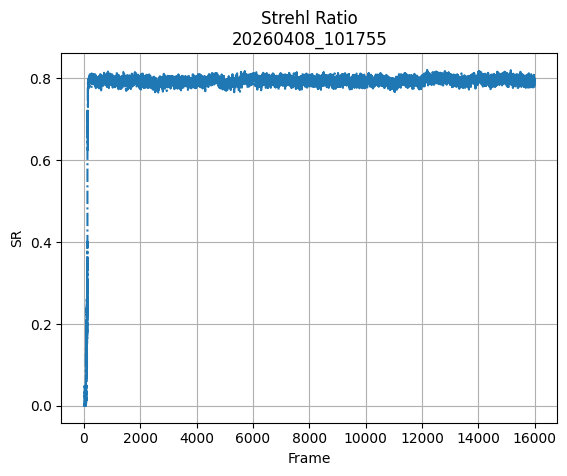

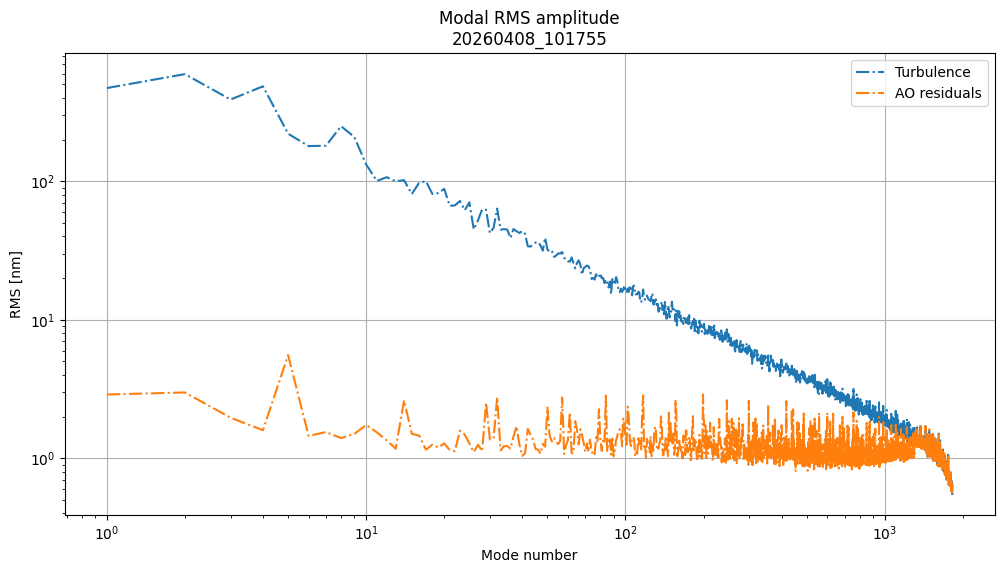

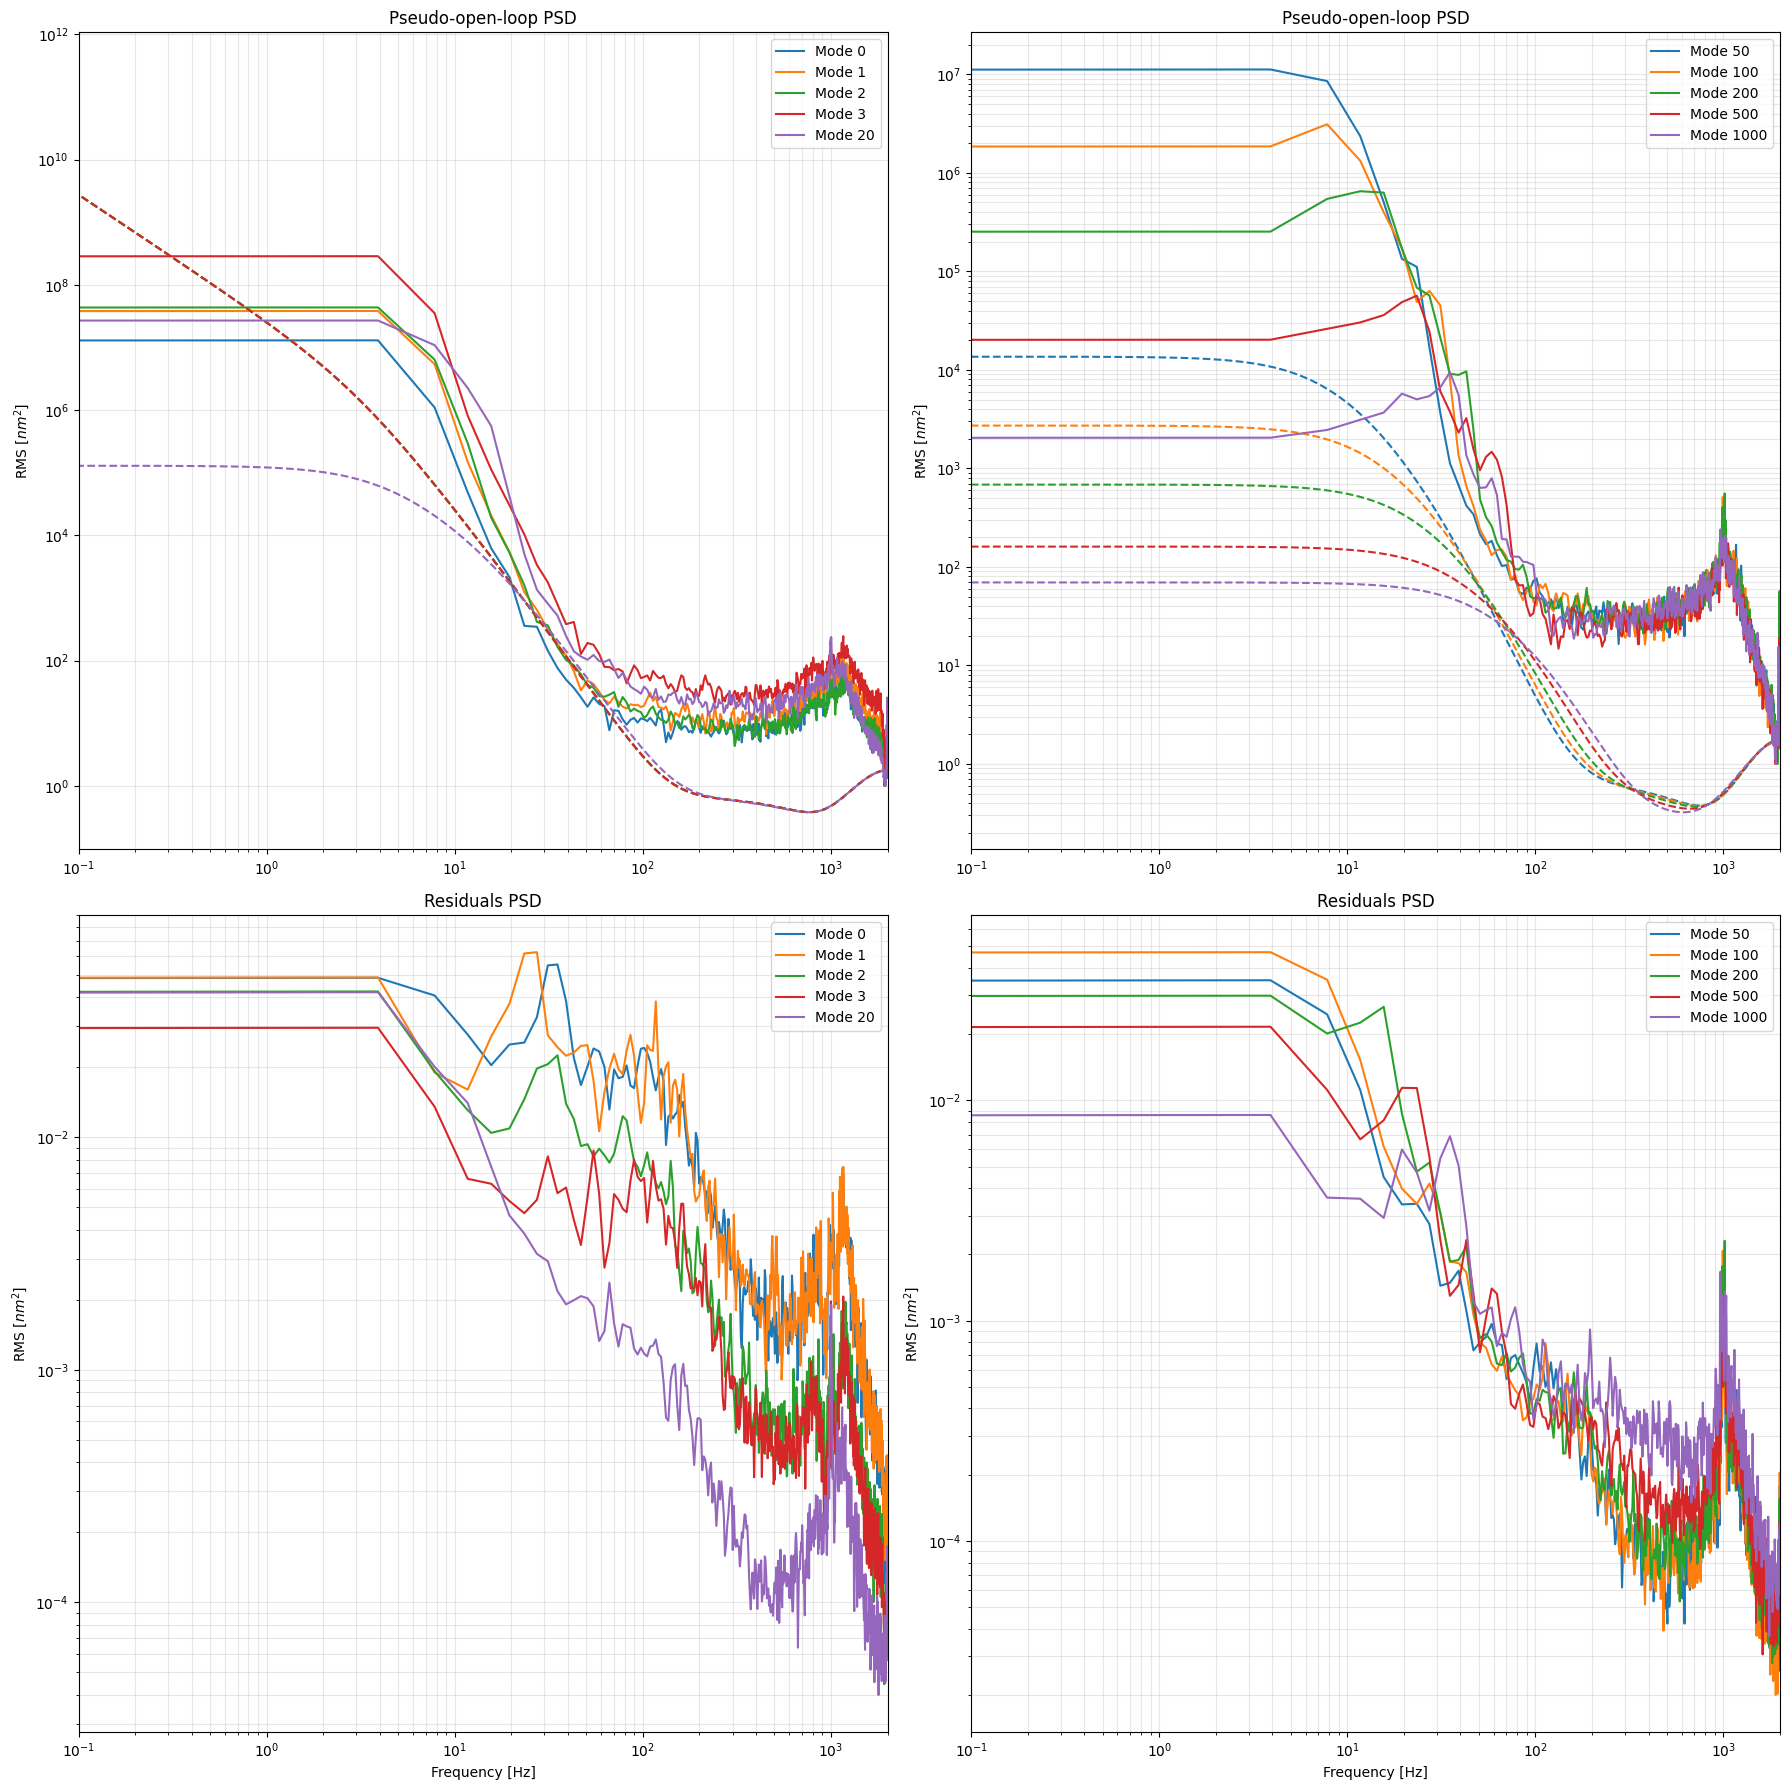

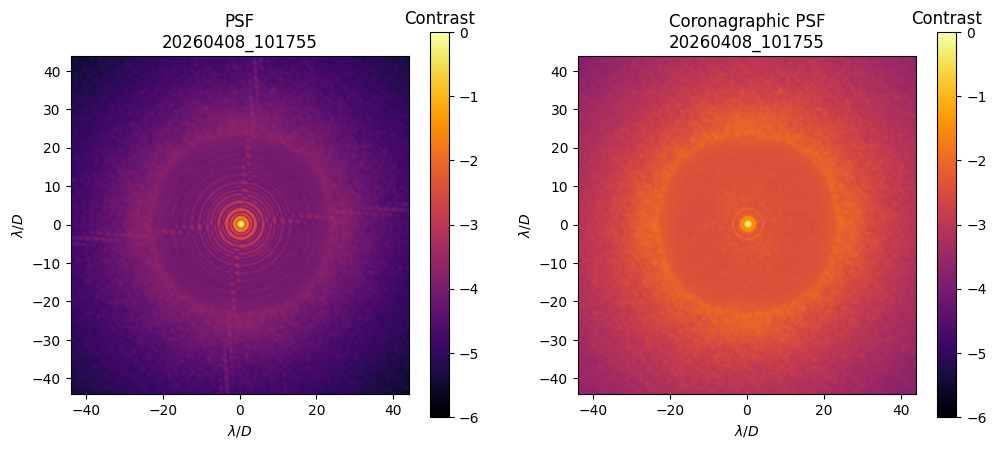

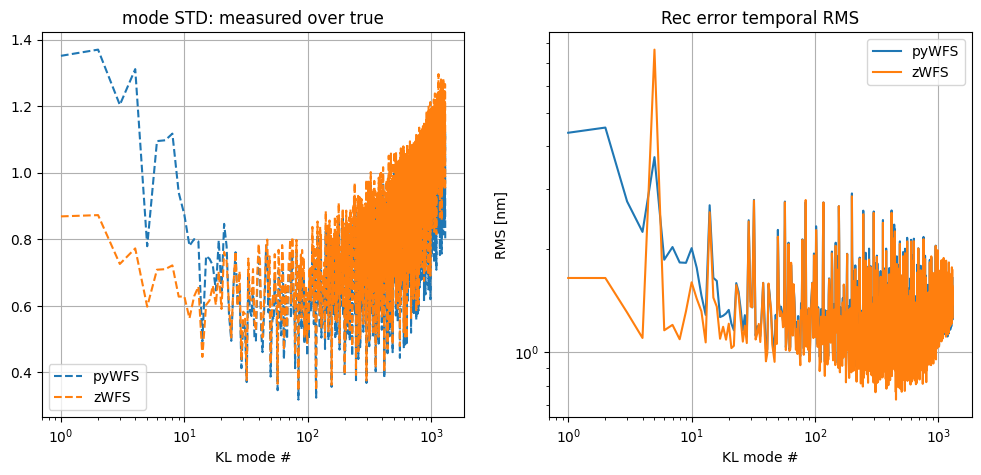

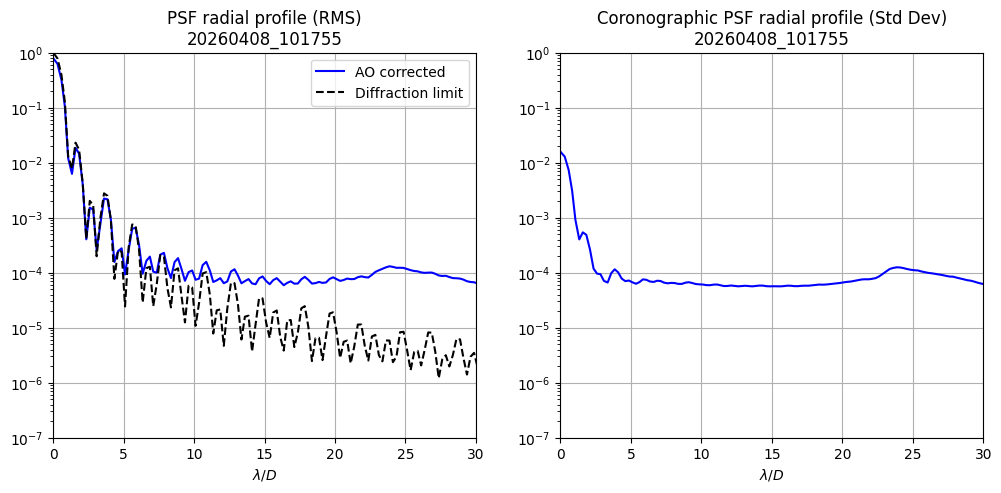

In [2]:
root_dir = '/raid1/mmenessini/results/XAO'
calib_dir = '/raid1/mmenessini/calibration/XAO'
plot_output_data(root_dir=root_dir,calib_dir=calib_dir)

In [3]:
# root_dir = '/raid1/mmenessini/calibration/XAO'
# check_calibration(root_dir)

In [4]:
# root_dir = '/raid1/mmenessini/calibration/XAO'
# Npix = 160

# compute_and_save_dcao_matrix(root_dir, first_stage_tag='bmc2k_vlt', second_stage_tag='dm468_vlt', N1_modes=1300, N2_modes=300)
# compute_and_save_dcao_matrix(root_dir, first_stage_tag='bmc2k_vlt', second_stage_tag='bmc2k_vlt', N1_modes=1300, N2_modes=300)

# compute_and_save_influence_functions(root_dir,tag='dm241_vlt', pupil_pixels=Npix, n_acts=17,
#                                         geom='alpao', r0=10e-2, obsratio=0.0, pupil_mask_tag='vlt_pupil')

# compute_and_save_influence_functions(root_dir,tag='dm468_vlt', pupil_pixels=Npix, n_acts=24,
#                                         geom='alpao', r0=10e-2, obsratio=0.0, pupil_mask_tag='vlt_pupil')

In [5]:
# gain_dir = '/raid1/mmenessini/results/Cascading'
# plot_gain_optimization(root_dir=gain_dir)

[0.9361942]


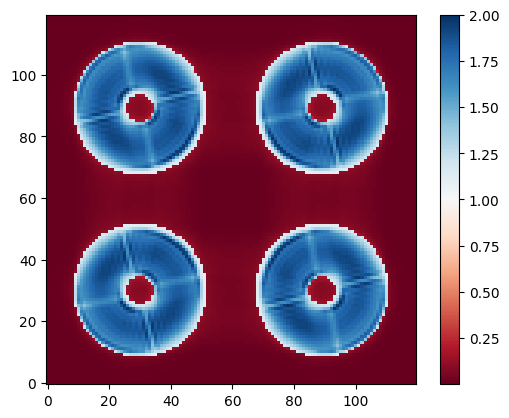

In [ ]:

# from specula.mmlib.utils import get_pupil_mask
# pupdatapath = '/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_40x40.fits'
# pyr_mask = get_pupil_mask(filepath=pupdatapath,npix=120,pyr=True)
# # plt.figure()
# # plt.imshow(pyr_mask,origin='lower')
# # plt.colorbar()

# frame = fits.getdata('/raid1/mmenessini/calibration/EKARUS/frames/pyr3.0_40x40_frame_null.fits')[0]    
# plt.figure()
# plt.imshow(frame/np.max(frame)+pyr_mask,origin='lower',cmap='RdBu')
# plt.colorbar()
# thrp = fits.getdata('/raid1/mmenessini/calibration/EKARUS/slopenulls/pyr3.0_40x40_throughput.fits')
# print(thrp)

(19416, 468) (468, 463) (463, 19416)


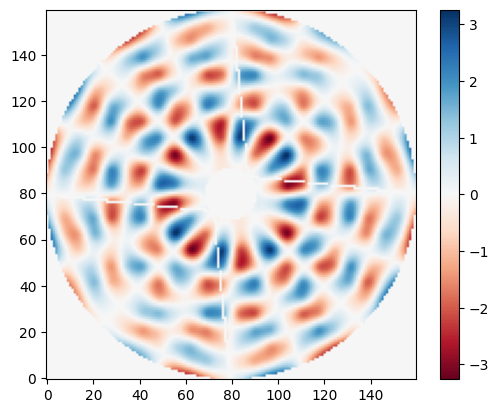

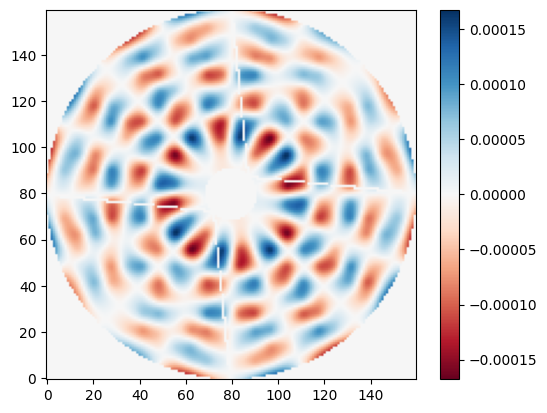

In [ ]:
# hdu = fits.open(f'/raid1/mmenessini/calibration/XAO/ifunc/dm468_vlt_ifunc.fits')
# IF = hdu[1].data
# hdu = fits.open(f'/raid1/mmenessini/calibration/XAO/ifunc/dm468_vlt_kl_inv.fits')
# KL = hdu[1].data
# hdu = fits.open(f'/raid1/mmenessini/calibration/XAO/m2c/dm468_vlt_m2c.fits')
# m2c = hdu[1].data


# fname = '/raid1/mmenessini/calibration/XAO/pupilstop/vlt_pupil_160pixels.fits'
# hdu = fits.open(fname)
# pupil_mask = hdu[1].data

# def show_img(flat_img):
#     img = np.zeros(pupil_mask.shape)
#     img[pupil_mask.astype(bool)] = flat_img
#     img = img.reshape(pupil_mask.shape)
#     plt.figure()
#     plt.imshow(img,origin='lower',cmap='RdBu')
#     plt.colorbar()


# print(IF.shape,m2c.shape,KL.shape)

# show_img(IF @ m2c[:,200])
# show_img(KL[200,:])



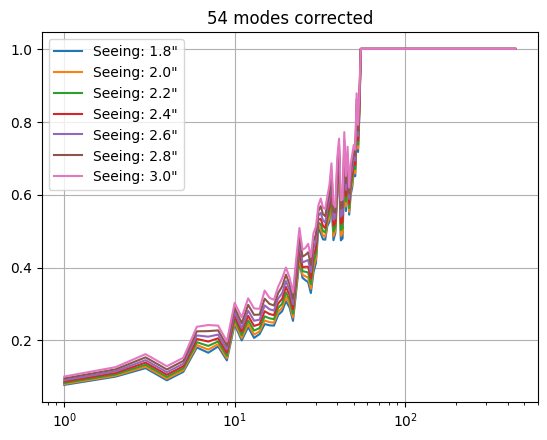

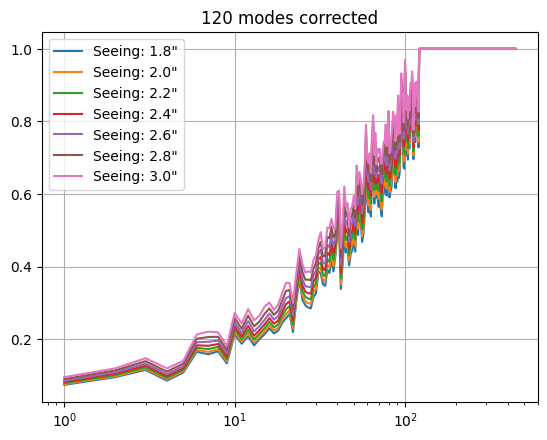

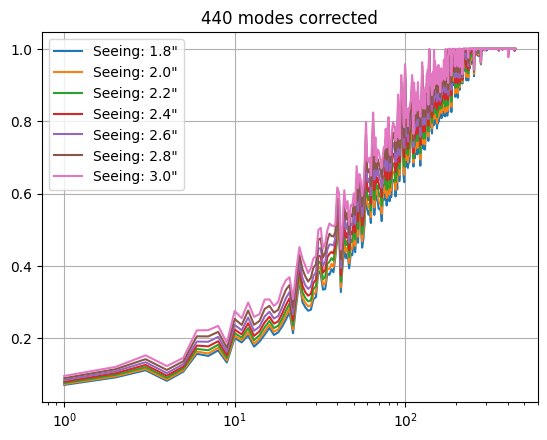

In [58]:

modes = np.array([54,120,440])
seeings = np.array([1.8,2.0,2.2,2.4,2.6,2.8,3.0])

cv = np.zeros([len(seeings),len(modes),443])

for i,seeing in enumerate(seeings):
    for j,N in enumerate(modes):
        cvec = fits.getdata(f'/raid1/mmenessini/calibration/EKARUS/data/s{seeing:1.1f}_{N:1.0f}modes_corrvec.fits')
        cvec = np.maximum(0.0,cvec)
        cv[i,j,:] = cvec
        fits.writeto(f'/raid1/mmenessini/calibration/EKARUS/data/s{seeing:1.1f}_{N:1.0f}modes_corrvec.fits',cvec,overwrite=True)

x = np.arange(443)+1

for j,N in enumerate(modes):
    plt.figure()
    for i,seeing in enumerate(seeings):
        plt.plot(x,1-cv[i,j,:],label=f'Seeing: {seeing:1.1f}"')
    plt.xscale('log')
    plt.legend()
    plt.title(f'{N:1.0f} modes corrected')
    plt.grid()

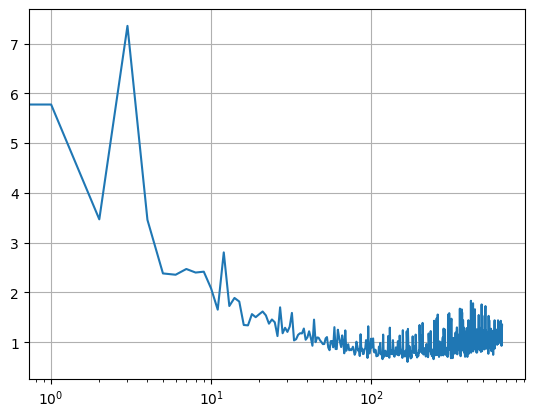

In [6]:
pyr_modes = fits.getdata('/raid1/mmenessini/calibration/SOUL/scratch_aliasing/pyr_modes.fits')

pyr_modes = np.sqrt(np.mean(pyr_modes**2,axis=0))

plt.figure()
plt.plot(pyr_modes)
plt.xscale('log')
plt.grid()

In [7]:
N = 54
atmo_modes = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/scratch_simpc/s0.6_{N}modes_atmo.fits')
atmo_modes = np.sqrt(np.mean(atmo_modes**2,axis=0))
print(np.sqrt(np.sum(atmo_modes[:N]**2)))
atmo_modes = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/scratch_simpc/s0.8_{N}modes_atmo.fits')
atmo_modes = np.sqrt(np.mean(atmo_modes**2,axis=0))
print(np.sqrt(np.sum(atmo_modes[:N]**2)))
atmo_modes = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/scratch_simpc/s1.0_{N}modes_atmo.fits')
atmo_modes = np.sqrt(np.mean(atmo_modes**2,axis=0))
print(np.sqrt(np.sum(atmo_modes[:N]**2)))
atmo_modes = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/scratch_simpc/s1.2_{N}modes_atmo.fits')
atmo_modes = np.sqrt(np.mean(atmo_modes**2,axis=0))
print(np.sqrt(np.sum(atmo_modes[:N]**2)))
atmo_modes = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/scratch_simpc/s1.4_{N}modes_atmo.fits')
atmo_modes = np.sqrt(np.mean(atmo_modes**2,axis=0))
print(np.sqrt(np.sum(atmo_modes[:N]**2)))

120.00357
167.83386
215.351
265.75635
322.44412


<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:37: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:37: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1434514/2026984214.py:22: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Optical Gains\n{rMod:1.0f} $\lambda/D$ pyWFS')
/tmp/ipykernel_1434514/2026984214.py:37: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Optical Gains\n{rMod:1.0f} $\lambda/D$ pyWFS')


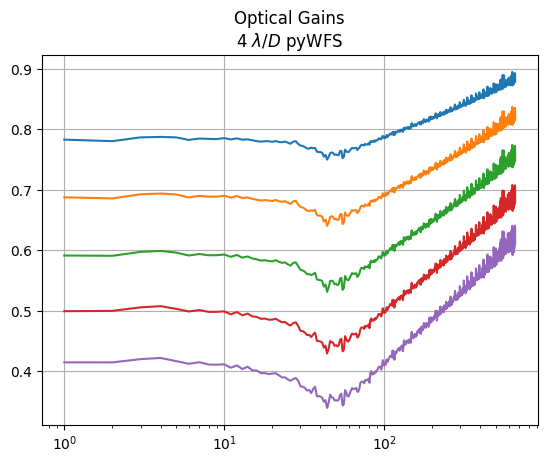

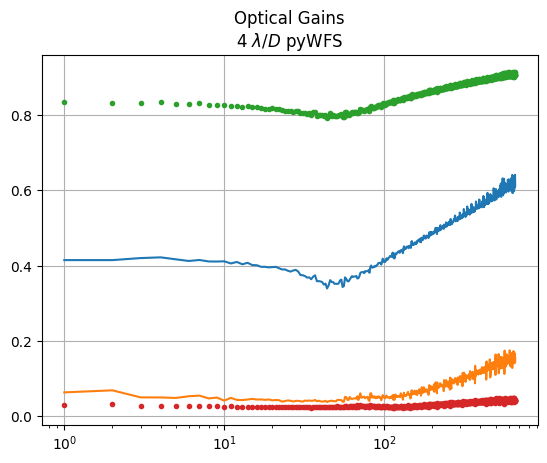

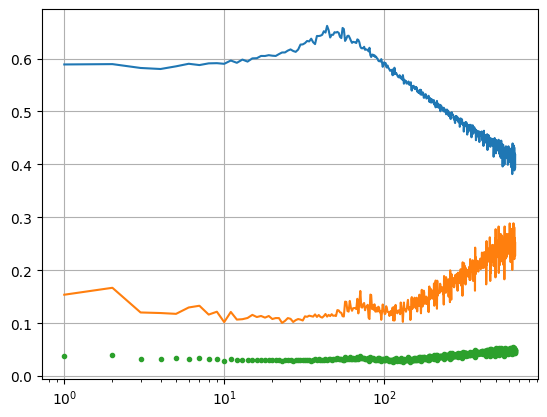

In [8]:
rMod = 4.0

ogs06 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s0.6_100Nm_og.fits')
ogs08 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s0.8_132Nm_og.fits')
ogs10 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s1.0_169Nm_og.fits')
ogs12 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s1.2_211Nm_og.fits')
ogs14 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s1.4_259Nm_og.fits')

im = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/im/pyr{rMod:1.1f}_40x40_im.fits')
simpc = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/im/pyr{rMod:1.1f}_40x40_s1.4_simpc.fits')
im_norm = np.diag(im.T @ im)
og = np.diag(simpc.T @ im)/im_norm
cog = np.sqrt(np.diag(simpc.T @ simpc)/im_norm - og**2)

x = np.arange(len(ogs06))+1
plt.figure()
plt.plot(x,ogs06)
plt.plot(x,ogs08)
plt.plot(x,ogs10)
plt.plot(x,ogs12)
plt.plot(x,ogs14)
plt.title(f'Optical Gains\n{rMod:1.0f} $\lambda/D$ pyWFS')
plt.xscale('log')
plt.grid()

plt.figure()
plt.plot(x,og)
plt.plot(x,cog)

im2 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/im/pyr{rMod:1.1f}_40x40_s1.2_simpc.fits')
im2_norm = np.diag(im2.T @ im2)
og2 = np.diag(simpc.T @ im2)/im2_norm
cog2 = np.sqrt(np.diag(simpc.T @ simpc)/im2_norm - og2**2)

plt.plot(x,og2,'.')
plt.plot(x,cog2,'.')
plt.title(f'Optical Gains\n{rMod:1.0f} $\lambda/D$ pyWFS')
plt.xscale('log')
plt.grid()

err = np.sqrt((1-og)**2+cog**2)
err_ogc = cog/og
err_ogc2 = cog2/og2

plt.figure()
plt.plot(x,err)
plt.plot(x,err_ogc)
plt.plot(x,err_ogc2,'.')
plt.xscale('log')
plt.grid()

<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:77: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:77: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1434514/2985049538.py:23: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Optical Gains\n{rMod:1.0f} $\lambda/D$ pyWFS')
/tmp/ipykernel_1434514/2985049538.py:77: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'OG estimation error\n{rMod:1.0f} $\lambda/D$ pyWFS')


57.66451603387616 2
64.57949274151 2
68.14698682261782 2
68.43732132751707 2
65.72947887333316 2
59.479267322975886 3
67.98548416185842 3
73.68797600430814 3
60.83756357206371 4
70.44143123870116 4
62.00405070165294 5
72.54392684120504 5
63.148162217271924 6
74.6468431867928 6


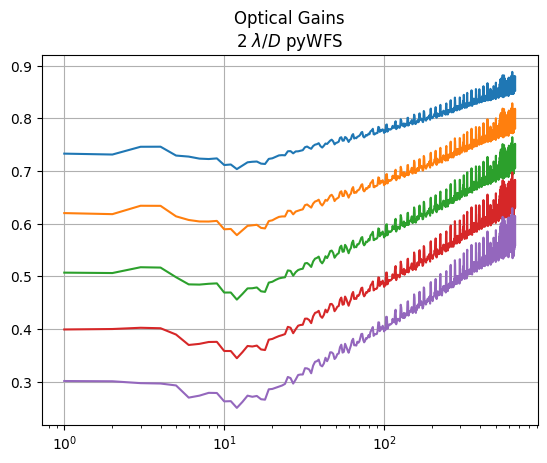

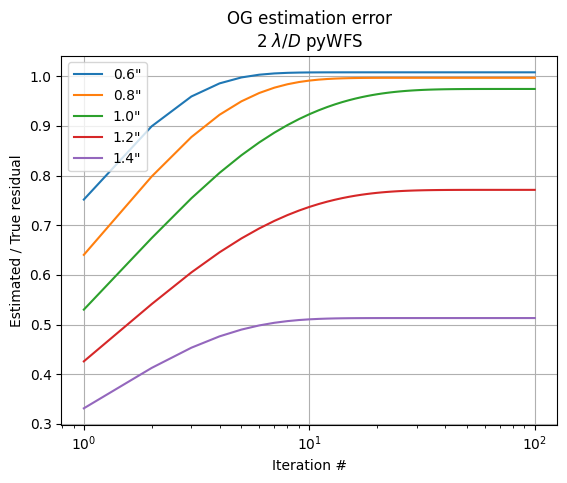

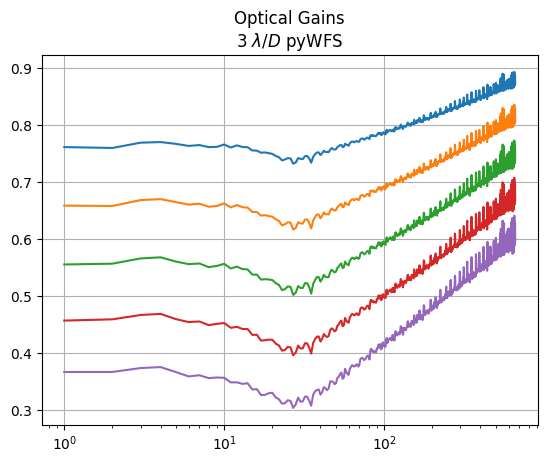

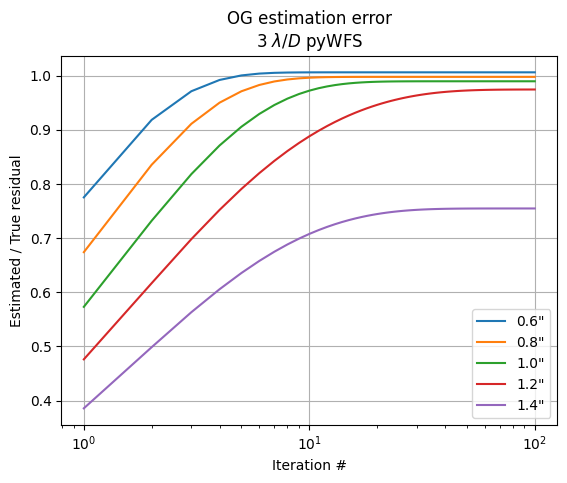

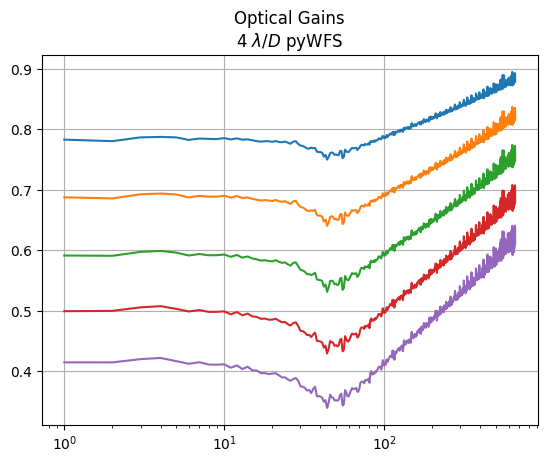

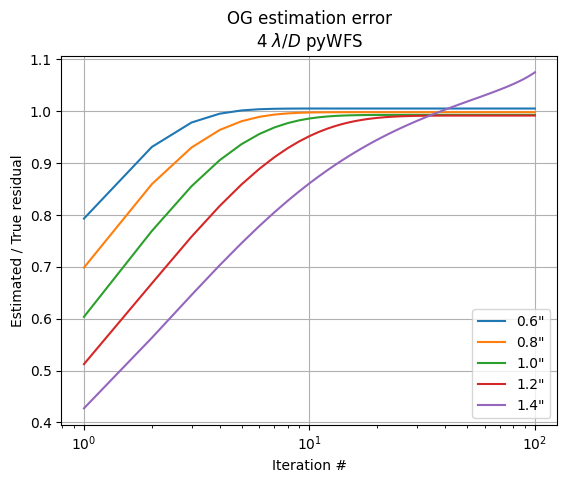

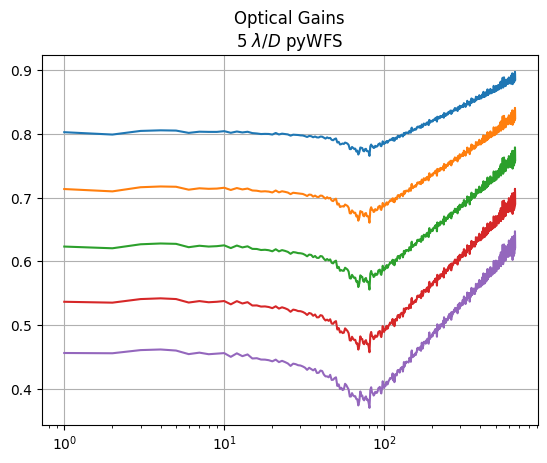

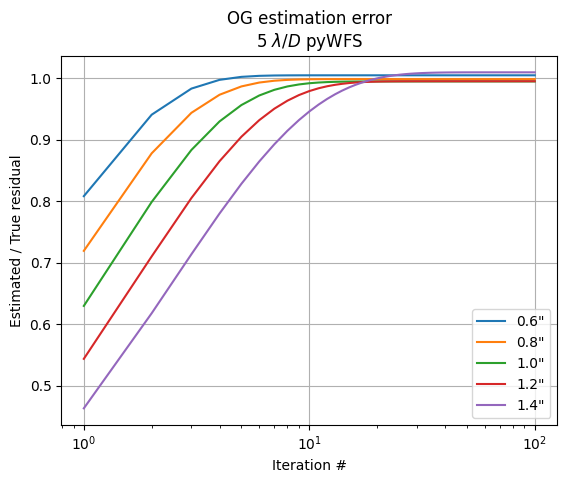

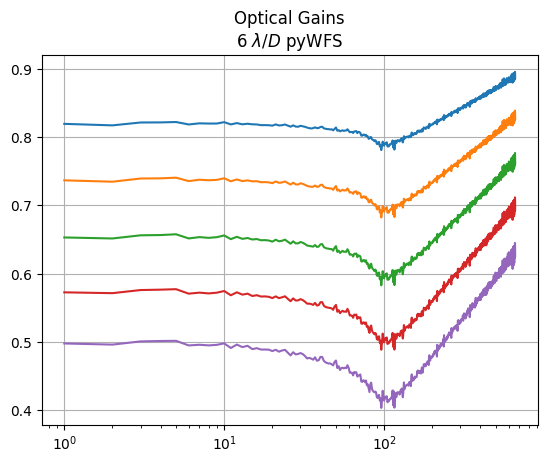

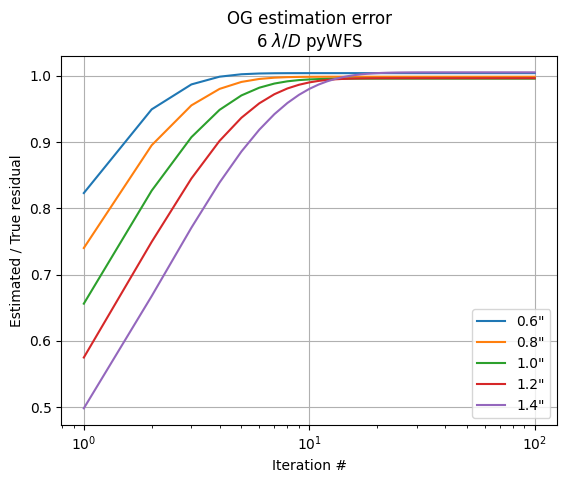

In [9]:
rMods = np.array([2,3,4,5,6])
res = np.array([76,101,129,161,198])

for k,rMod in enumerate(rMods):

    ogs06 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s0.6_100Nm_og.fits')
    ogs08 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s0.8_132Nm_og.fits')
    ogs10 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s1.0_169Nm_og.fits')
    ogs12 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s1.2_211Nm_og.fits')
    ogs14 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s1.4_259Nm_og.fits')

    ogs = np.vstack([ogs06,ogs08,ogs10,ogs12,ogs14])
    extrapolator = interp1d(res, ogs, axis=0, kind='cubic', fill_value="extrapolate")
    # extrapolator = interp1d(res, ogs, axis=0, kind='linear', fill_value="extrapolate")

    x = np.arange(len(ogs06))+1
    plt.figure()
    plt.plot(x,ogs06)
    plt.plot(x,ogs08)
    plt.plot(x,ogs10)
    plt.plot(x,ogs12)
    plt.plot(x,ogs14)
    plt.title(f'Optical Gains\n{rMod:1.0f} $\lambda/D$ pyWFS')
    plt.xscale('log')
    plt.grid()

    seeings = np.arange(5)*0.2+0.6
    Nits = 100

    pol_values = np.zeros([len(seeings),Nits])

    for j,seeing in enumerate(seeings):
        og = ogs[j]
        atmo_modes = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/scratch_simpc/s{seeing:1.1f}_660modes_atmo.fits')
        atmo_modes = np.sqrt(np.mean(atmo_modes**2,axis=0))

        atmo_modes = atmo_modes[:len(ogs[0])]
        meas_modes = og * atmo_modes
        x = np.arange(len(atmo_modes))+1

        true_res = np.sqrt(np.sum(atmo_modes**2))
        meas_res = np.sqrt(np.sum(meas_modes**2))

        # plt.figure()
        # plt.plot(x,atmo_modes,label=f'True, res = {true_res:1.0f}')
        # plt.plot(x,meas_modes,'--',label=f'Measured, res = {meas_res:1.0f}')
        # plt.legend()
        # plt.xscale('log')
        # plt.yscale('log')
        # plt.grid()

        pol_res = meas_res
        if pol_res < min(res):
            print(pol_res,rMod)

        # plt.figure()
        # plt.plot(x,og,label=f'True')
        for i in range(100):
            est_ogs = extrapolator(pol_res)
            # if i % 20 == 0:
            #     plt.plot(x,est_ogs,'--',label=f'Iteration {i}, res = {pol_res:1.0f}')
            pol_values[j,i] = pol_res / true_res
            pol_modes = meas_modes / est_ogs
            pol_res = np.sqrt(np.sum(pol_modes**2))
        # plt.legend()
        # plt.xscale('log')
        # plt.grid()

    plt.figure()
    for j,seeing in enumerate(seeings):
        plt.plot(np.arange(Nits)+1,pol_values[j],label=f'{seeing:1.1f}"')
    plt.xscale('log')
    plt.legend()
    plt.grid()
    plt.xlabel('Iteration #')
    plt.ylabel('Estimated / True residual')
    plt.title(f'OG estimation error\n{rMod:1.0f} $\lambda/D$ pyWFS')

In [10]:
# id = 600

# ogs_id = np.array([ogs06[id],ogs08[id],ogs10[id],ogs12[id],ogs14[id]])

# p = np.polyfit(res,ogs_id,2)

# res2 = np.linspace(10,1000)

# plt.figure()
# plt.plot(res,ogs_id,'o')
# plt.plot(res2,np.polyval(p,res2),'--')
# plt.grid()

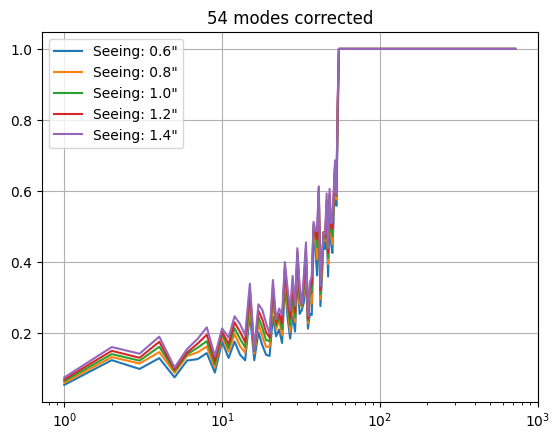

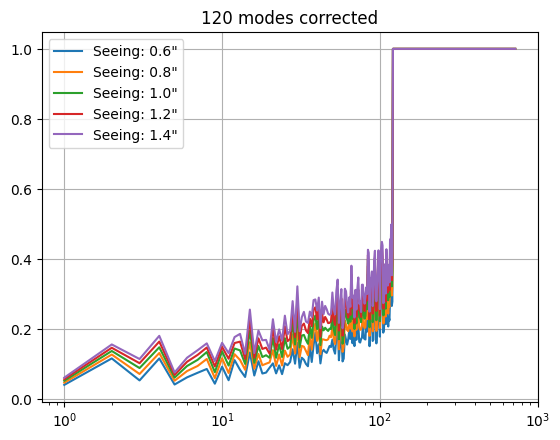

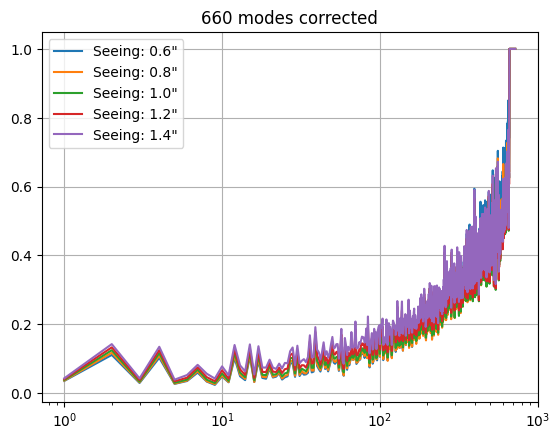

In [11]:
seeings = np.array([0.6,0.8,1.0,1.2,1.4])
modes = np.array([54,120,660])

cv = np.zeros([len(seeings),len(modes),720])

for i,seeing in enumerate(seeings):
    for j,N in enumerate(modes):
        cv[i,j,:] = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/data/s{seeing:1.1f}_{N:1.0f}modes_corrvec.fits')

x = np.arange(720)+1

for j,N in enumerate(modes):
    plt.figure()
    for i,seeing in enumerate(seeings):
        plt.plot(x,1-cv[i,j,:],label=f'Seeing: {seeing:1.1f}"')
    plt.xscale('log')
    plt.legend()
    plt.title(f'{N:1.0f} modes corrected')
    plt.grid()